In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import datetime as dt
from sklearn.neighbors import NearestNeighbors
from itertools import combinations
from collections import defaultdict
from sklearn.cluster import SpectralClustering
from math import isnan
from random import sample
from numpy.random import uniform
from networkx.algorithms.community import louvain_communities, modularity
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Download Data

In [55]:
# import kagglehub

# Download latest version
# path = kagglehub.dataset_download("hellbuoy/online-retail-customer-clustering")

# print("Path to dataset files:", path)

Move this CSV file to the same directory as the Jupyter Notebook.

### Step 1: Load Data

In [56]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')
display(df.head())
display(df.tail())
print(df.shape)
print(df.info())
print(df.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12:50,4.95,12680.0,France


(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000   

### Step 2: Data Cleaning and Preprocessing

In [57]:
# --- Preprocessing ---
df_cleaned = df.copy()

# 1. Remove null CustomerIDs
df_cleaned.dropna(subset=['CustomerID'], inplace=True)

# 2. Remove Non-Product StockCodes (Crucial for accurate 'Monetary' and 'Frequency')
# POST=Postage, D=Discount, M=Manual, C2=Carriage, PADs=Pads, DOT=Dotcom postage, CRUK=CRUK Commission
non_product_codes = ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']
df_cleaned = df_cleaned[~df_cleaned['StockCode'].isin(non_product_codes)]

# 3. Filter for United Kingdom only
# This removes bias from international shipping costs/bulk exports
df_cleaned = df_cleaned[df_cleaned['Country'] == 'United Kingdom']

# 4. Remove returns (negative quantity) and zero prices
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)]

# 5. formatting
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'], format='%d-%m-%Y %H:%M')
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

print(f"Final Cleaned Shape: {df_cleaned.shape}")

Final Cleaned Shape: (353985, 9)


### Step 3: RFM (Recency, Frequency, Monetary) Feature Engineering

Recency: Days since last purchase.

Frequency: Count of unique invoices.

Monetary: Total money spent.

In [58]:
# 1. Determine the reference date (1 day after the last transaction)
snapshot_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot Date: {snapshot_date}")

# 2. Calculate Recency, Frequency, and Monetary metrics
rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: days since last purchase
    'InvoiceNo': 'nunique',                                   # Frequency: count of unique invoices
    'TotalPrice': 'sum'                                       # Monetary: total spend
})

# 3. Rename columns for clarity
rfm.rename(columns={'InvoiceDate': 'Recency', 
                    'InvoiceNo': 'Frequency', 
                    'TotalPrice': 'Monetary'}, inplace=True)

# 4. Display summary
print(f"\nRFM Data Shape: {rfm.shape}")
print("\nRFM Head:")
display(rfm.head())
print("\nRFM Description:")
display(rfm.describe())

Snapshot Date: 2011-12-10 12:49:00

RFM Data Shape: (3916, 3)

RFM Head:


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12747,2,11,4196.01
12748,1,206,32317.32
12749,4,5,4040.88
12820,3,4,942.34



RFM Description:


,Recency,Frequency,Monetary
count,3916.000000,3916.000000,3916.000000
mean,92.352656,4.233657,1855.429579
std,99.717788,7.155153,7436.608965
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,299.535000
50%,51.000000,2.000000,650.470000
75%,143.000000,5.000000,1571.450000
max,374.000000,206.000000,259657.300000


### Step 4: Data Transformation and Scaling

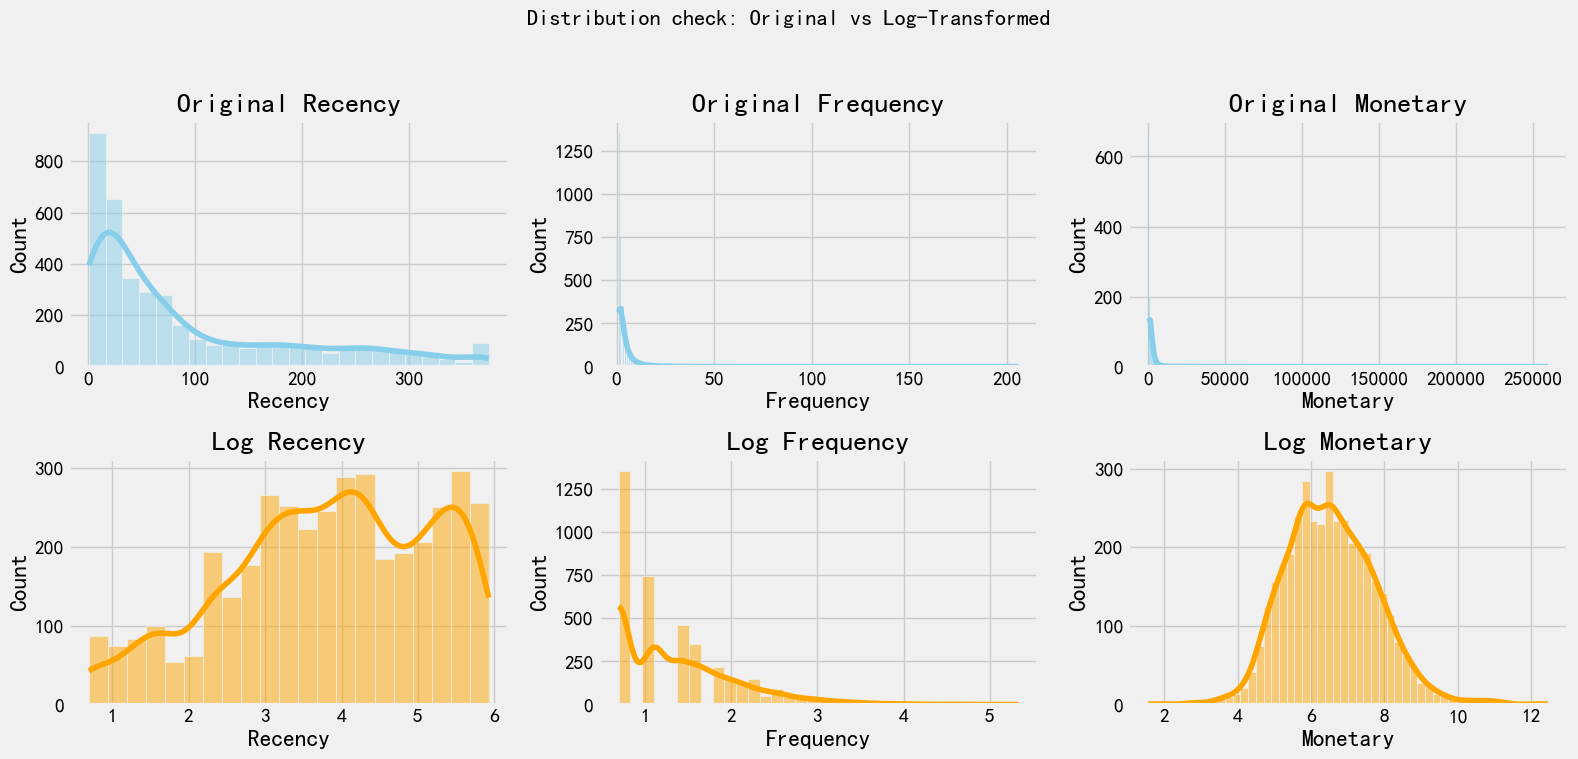


Scaled Data Head:


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.462551,-0.956444,3.790509
12747,-2.035318,1.673291,1.446981
12748,-2.337633,5.852977,3.089851
12749,-1.654446,0.655971,1.416669
12820,-1.820822,0.388380,0.245610


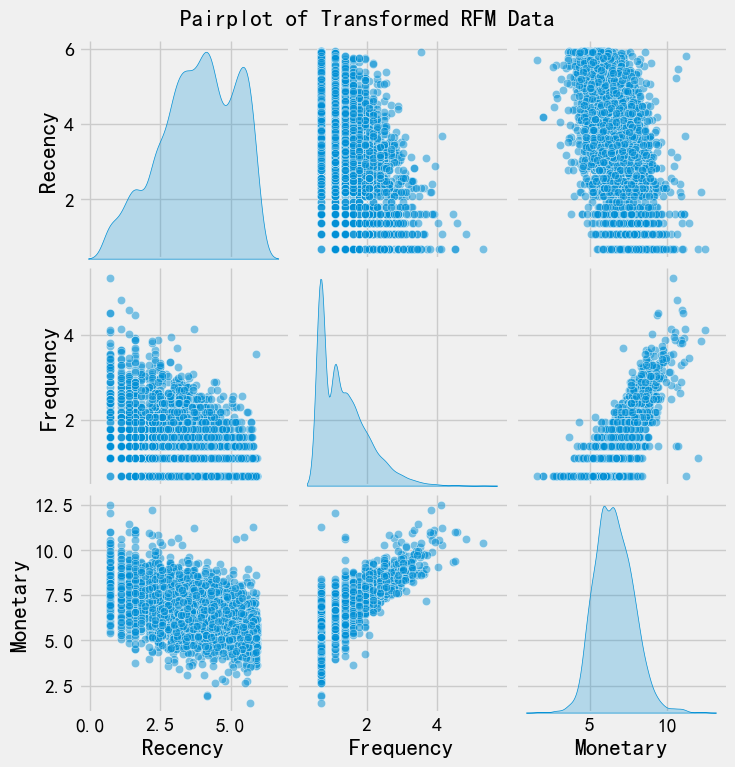


Hopkins Statistic: 0.9549


In [59]:
# --- A. Log Transformation (Handle Skewness) ---
# We add 1 to handle potential zeros, though normally RFM shouldn't have zeros if cleaned well
rfm_log = np.log(rfm + 1)

# --- B. Visualization: Distributions (Before vs. After) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution check: Original vs Log-Transformed', fontsize=16)

# Original Data
sns.histplot(rfm['Recency'], ax=axes[0, 0], kde=True, color='skyblue').set_title('Original Recency')
sns.histplot(rfm['Frequency'], ax=axes[0, 1], kde=True, color='skyblue').set_title('Original Frequency')
sns.histplot(rfm['Monetary'], ax=axes[0, 2], kde=True, color='skyblue').set_title('Original Monetary')

# Log-Transformed Data
sns.histplot(rfm_log['Recency'], ax=axes[1, 0], kde=True, color='orange').set_title('Log Recency')
sns.histplot(rfm_log['Frequency'], ax=axes[1, 1], kde=True, color='orange').set_title('Log Frequency')
sns.histplot(rfm_log['Monetary'], ax=axes[1, 2], kde=True, color='orange').set_title('Log Monetary')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- C. Scaling (StandardScaler) ---
scaler = StandardScaler()
rfm_scaled_np = scaler.fit_transform(rfm_log)
# Convert back to DataFrame for readability and indices
rfm_scaled = pd.DataFrame(rfm_scaled_np, index=rfm.index, columns=rfm.columns)

print("\nScaled Data Head:")
display(rfm_scaled.head())

# --- D. Pairplot (Visualizing Clusters Tendency) ---
sns.pairplot(rfm_log, diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of Transformed RFM Data', y=1.02)
plt.show()

# --- E. Hopkins Statistic (Mathematical Validation) ---
def hopkins(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n) # Sample 10% of the data
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
    
    rand_X = sample(range(0, n, 1), m)
    
    ujd = []
    wjd = []
    for j in range(0, m):
        # Distance from random uniform points to nearest neighbor in X
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        # Distance from real points to nearest neighbor
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
        
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H): H = 0
    return H

# Calculate and print
hopkins_score = hopkins(rfm_scaled)
print(f"\nHopkins Statistic: {hopkins_score:.4f}")

A score > 0.7 shows it has high clustering tendency means is good for K-Means

### Step 5: General Clustering Algorithms (K-means & Hierarchical Clustering)

K-Means

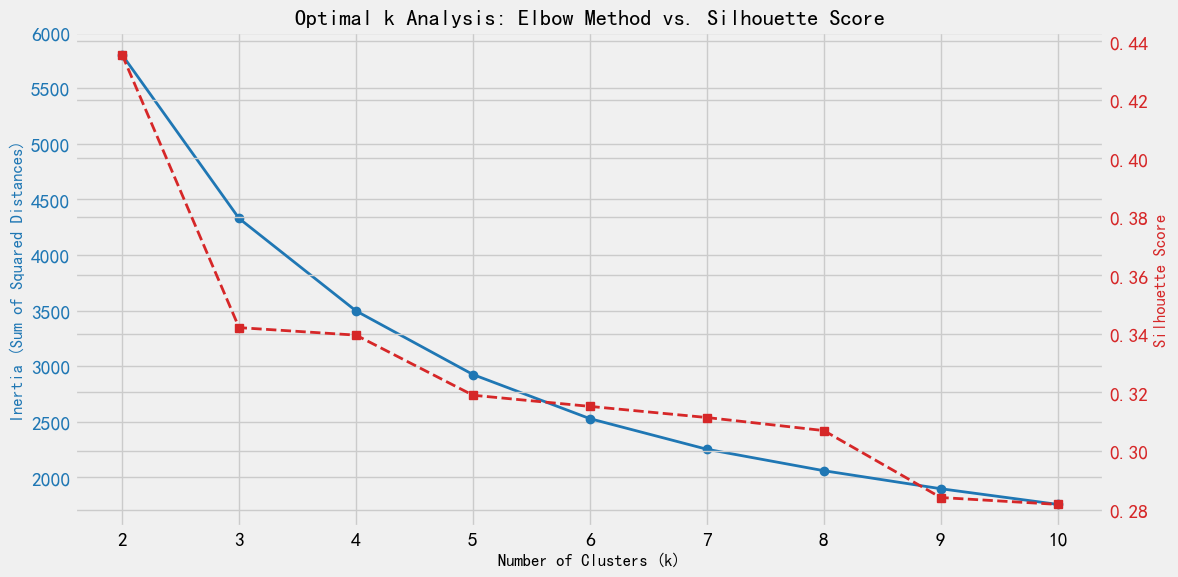

In [60]:
# Initialize lists to store metrics
inertia = []
silhouette_scores = []
K_range = range(2, 11)  # Testing k from 2 to 10

for k in K_range:
    # n_init=10 suppresses warnings and ensures stable results
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(rfm_scaled)
    
    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans_test.labels_))

# Plotting the Dual-Axis Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (Elbow Curve)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color, fontsize=12)
ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(visible=True, axis='x') # Vertical grid lines only

# Plot Silhouette Score
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal k Analysis: Elbow Method vs. Silhouette Score', fontsize=16)
fig.tight_layout() 
plt.show()

According to above result, the best k = 3

Running K-Means with k=3...

--- K-Means Results (k=3) ---
Davies-Bouldin Index: 1.0329
Silhouette Score:     0.3422


c:\Users\fhuur\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


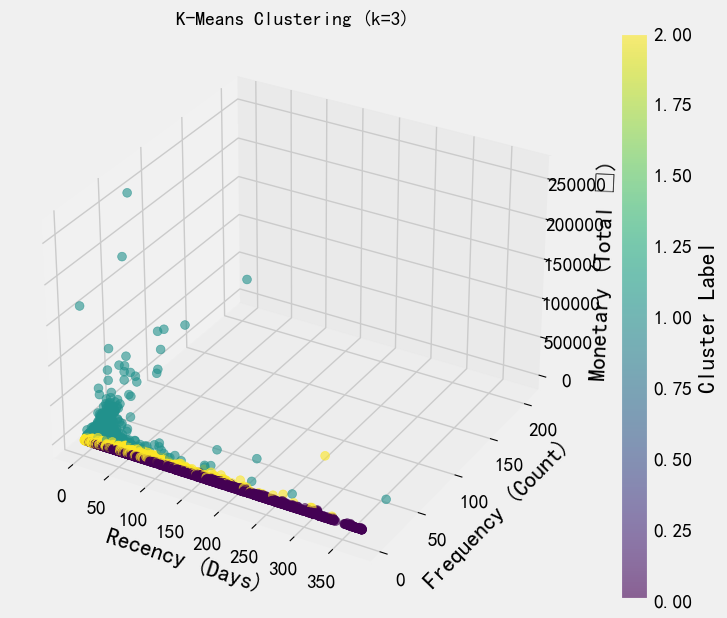


Cluster Profiling (Mean Values):


,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,165.86,1.35,345.80
1,17.12,13.27,7120.46
2,43.53,3.43,1197.06


In [61]:
best_k = 3  

print(f"Running K-Means with k={best_k}...")

# 2. Apply K-Means
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(rfm_scaled)

# 3. Assign labels back to the main dataframe
rfm['KMeans_Cluster'] = kmeans_labels

# 4. Evaluation Metrics (As requested in PDF)
km_db_index = davies_bouldin_score(rfm_scaled, kmeans_labels)
km_sil_score = silhouette_score(rfm_scaled, kmeans_labels)

print(f"\n--- K-Means Results (k={best_k}) ---")
print(f"Davies-Bouldin Index: {km_db_index:.4f}")
print(f"Silhouette Score:     {km_sil_score:.4f}")

# 5. Visualize in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                c=rfm['KMeans_Cluster'], cmap='viridis', s=40, alpha=0.6)

ax.set_title(f'K-Means Clustering (k={best_k})', fontsize=14)
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Count)')
ax.set_zlabel('Monetary (Total £)')
plt.colorbar(sc, label='Cluster Label')
plt.show()

# 6. Interpret the Clusters (Mean values per cluster)
print("\nCluster Profiling (Mean Values):")
display(rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

Hierarchical Clustering

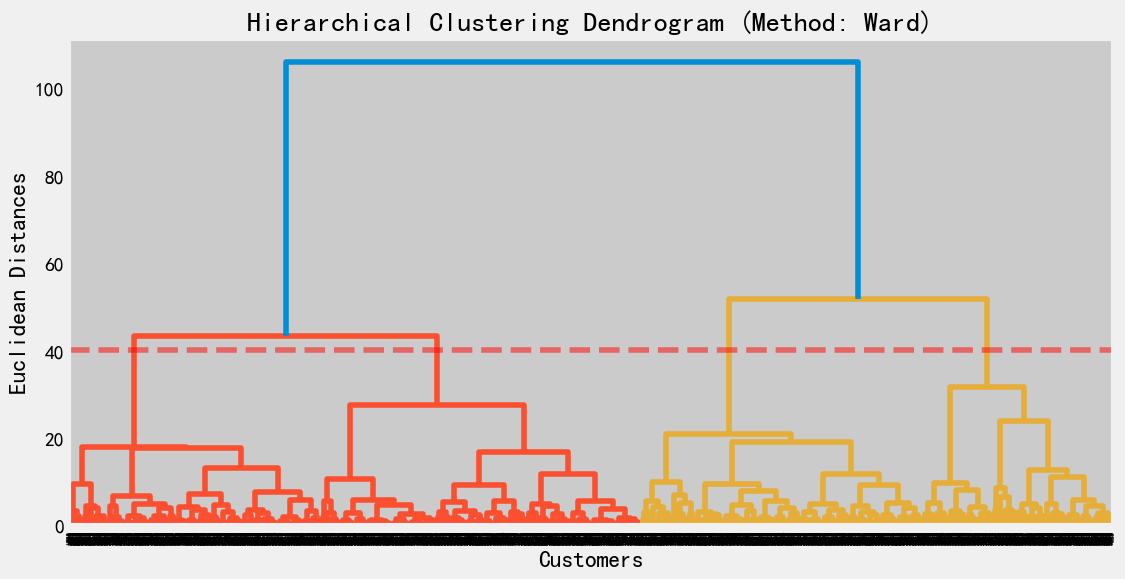

Running Hierarchical Clustering with k=3...

--- Hierarchical Clustering Results (k=3) ---
Davies-Bouldin Index: 1.1157
Silhouette Score:     0.3034

--- Model Comparison ---
Conclusion: K-Means performed better (Lower DB Index).


In [62]:
# 1. Dendrogram (Visualization of the hierarchy)
plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Method: Ward)")
# Linkage matrix using 'ward' minimization
dend = dendrogram(linkage(rfm_scaled, method='ward'))
plt.xlabel("Customers")
plt.ylabel("Euclidean Distances")
# Draw a line to show where we cut (optional, purely visual)
plt.axhline(y=40, color='r', linestyle='--', alpha=0.5) 
plt.show()

print(f"Running Hierarchical Clustering with k={best_k}...")

# 2. Apply Agglomerative Clustering
# We use the same k as K-Means to make a fair comparison
hc = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(rfm_scaled)

# 3. Assign labels to dataframe
rfm['Hierarchy_Cluster'] = hc_labels

# 4. Evaluation Metrics
hc_db_index = davies_bouldin_score(rfm_scaled, hc_labels)
hc_sil_score = silhouette_score(rfm_scaled, hc_labels)

print(f"\n--- Hierarchical Clustering Results (k={best_k}) ---")
print(f"Davies-Bouldin Index: {hc_db_index:.4f}")
print(f"Silhouette Score:     {hc_sil_score:.4f}")

# 5. Compare the two models
print("\n--- Model Comparison ---")
improvement = ((km_db_index - hc_db_index) / km_db_index) * 100
if km_db_index < hc_db_index:
    print(f"Conclusion: K-Means performed better (Lower DB Index).")
else:
    print(f"Conclusion: Hierarchical performed better (Lower DB Index).")

### Step 6: Graph-Based Clustering (Spectral Clustering and Louvain Algorithm)

Constructing the Graph

In [63]:
# 1. Create Customer-Item Matrix
print("1. Creating Customer-Item Matrix...")
customer_item_matrix = df_cleaned.pivot_table(
    index='CustomerID', 
    columns='StockCode', 
    values='Quantity', 
    aggfunc='sum'
).fillna(0)
customer_item_matrix = customer_item_matrix.map(lambda x: 1 if x > 0 else 0)

# 2. Calculate Cosine Similarity Matrix
print("2. Calculating Cosine Similarity (N x N)...")
# This creates a matrix where value = how similar two customers are (0 to 1)
sim_matrix = cosine_similarity(customer_item_matrix)

# 3. Build the Graph (Thresholding)
# We connect customers if their similarity is > 0.1
# This is the 'Edge Creation' step.
threshold = 0.1 
print(f"3. Building Graph with Similarity Threshold > {threshold}...")

# Create Adjacency Matrix: 1 if sim > 0.1, else 0
adjacency = (sim_matrix > threshold).astype(int)
# Remove self-loops (diagonal)
np.fill_diagonal(adjacency, 0)

# Convert to NetworkX Graph
G = nx.from_numpy_array(adjacency)
# Relabel nodes to use actual CustomerIDs
mapping = {i: cust_id for i, cust_id in enumerate(customer_item_matrix.index)}
G = nx.relabel_nodes(G, mapping)

print(f"   Graph Stats: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")
print(f"   Density: {nx.density(G):.4f}")

1. Creating Customer-Item Matrix...
2. Calculating Cosine Similarity (N x N)...
3. Building Graph with Similarity Threshold > 0.1...
   Graph Stats: 3916 nodes, 748078 edges.
   Density: 0.0976


Spectral Clustering

In [64]:
# Run Spectral Clustering using the precomputed similarity matrix
spectral = SpectralClustering(
    n_clusters=3, 
    affinity='precomputed', # We use the cosine similarity matrix directly
    random_state=42,
    n_init=10
)

# Fit to the similarity matrix
spectral_labels = spectral.fit_predict(sim_matrix)

# Assign labels to DataFrame
rfm.loc[customer_item_matrix.index, 'Spectral_Cluster'] = spectral_labels

# Calculate Modularity (Evaluation Measure)
spec_communities = []
for i in range(3):
    members = rfm[rfm['Spectral_Cluster'] == i].index
    # Only keep members that are actually in the graph
    valid_members = [n for n in members if n in G.nodes()]
    spec_communities.append(set(valid_members))

try:
    spec_mod = modularity(G, spec_communities)
    print(f"   Spectral Clustering Modularity: {spec_mod:.4f}")
except Exception as e:
    print(f"   Modularity calculation skipped (Graph might be too fragmented). Error: {e}")

print(f"   Cluster Counts: {rfm['Spectral_Cluster'].value_counts().to_dict()}")

   Spectral Clustering Modularity: 0.0000
   Cluster Counts: {0.0: 3912, 2.0: 2, 1.0: 2}


Louvain Algorithm

In [65]:
# Louvain optimizes Modularity directly
louvain_comms = louvain_communities(G, seed=42)

# Assign labels
rfm['Louvain_Cluster'] = -1
for cluster_id, nodes in enumerate(louvain_comms):
    valid_nodes = [n for n in nodes if n in rfm.index]
    rfm.loc[valid_nodes, 'Louvain_Cluster'] = cluster_id

# Calculate Modularity
louvain_mod = modularity(G, louvain_comms)

print(f"   Louvain Results:")
print(f"   Modularity: {louvain_mod:.4f}")
print(f"   Communities Found: {len(louvain_comms)}")
print(f"   Top 3 Community Sizes: {rfm['Louvain_Cluster'].value_counts().head(3).to_dict()}")

   Louvain Results:
   Modularity: 0.2040
   Communities Found: 8
   Top 3 Community Sizes: {7: 1585, 6: 1139, 1: 768}


Visualization Louvain Results

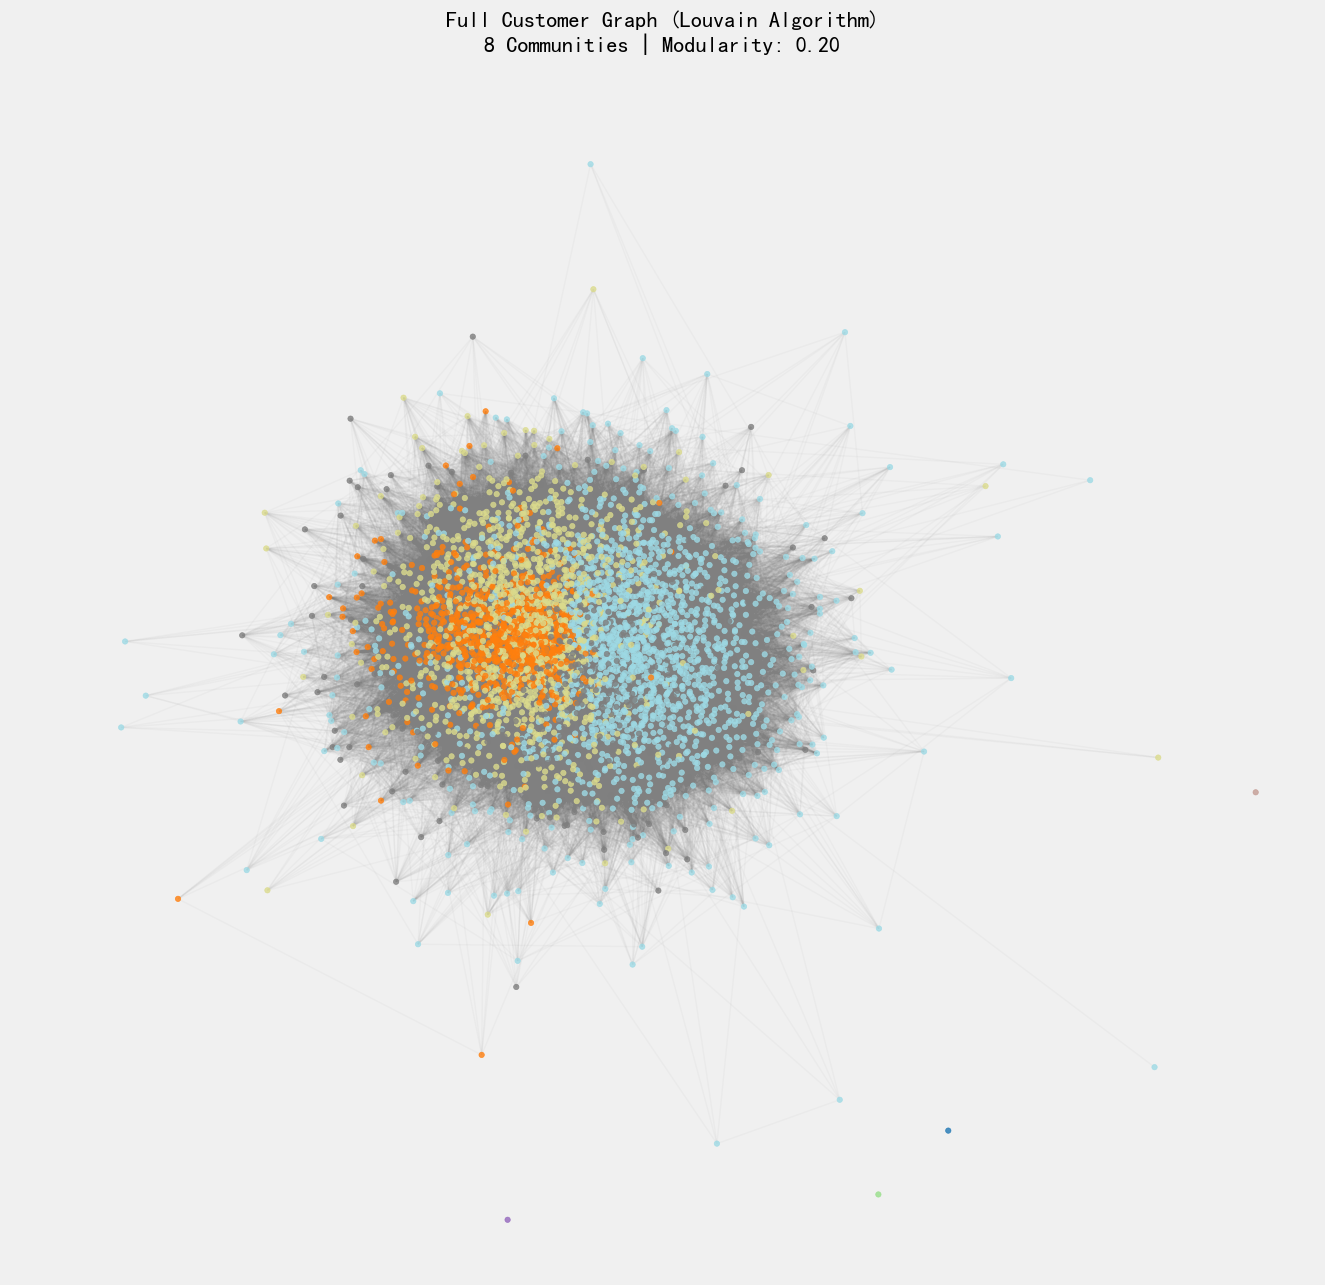

In [66]:
plt.figure(figsize=(15, 15))

# 1. Calculate Layout for the whole graph
# We use fewer iterations (30) to speed up the calculation for 4000 nodes
pos = nx.spring_layout(G, k=0.15, seed=42, iterations=30)

# 2. Map Colors
# Use a specific color for 'Noise' or '-1' if any, otherwise map normally
node_colors = [rfm.loc[n, 'Louvain_Cluster'] for n in G.nodes()]

# 3. Draw Nodes (Made smaller to fit them all)
nx.draw_networkx_nodes(G, pos, 
                       node_color=node_colors, 
                       cmap='tab20', 
                       node_size=15,  # Small size for mass visualization
                       alpha=0.8)

# 4. Draw Edges (Very faint to avoid blocking the view)
nx.draw_networkx_edges(G, pos, 
                       alpha=0.05,  # Very transparent
                       edge_color='gray')

# 5. Title
n_communities = rfm['Louvain_Cluster'].nunique()
plt.title(f"Full Customer Graph (Louvain Algorithm)\n{n_communities} Communities | Modularity: {louvain_mod:.2f}", fontsize=16)
plt.axis('off')
plt.show()

Analysis of Louvain Communities


--- Louvain Community Profile (Who are they?) ---


,Community ID,Size,Avg Spend (£),Avg Frequency,Top Products
0,7,1585,1480.04,3.4,"WHITE HANGING HEART T-LIGHT HOLDER, REGENCY CAKESTAND 3 TIER, ASSORTED COLOUR BIRD ORNAMENT"
1,6,1139,1953.93,4.3,"PAPER CHAIN KIT 50'S CHRISTMAS , VINTAGE SNAP CARDS, SET OF 4 PANTRY JELLY MOULDS"
2,1,768,2819.80,6.2,"JUMBO BAG RED RETROSPOT, LUNCH BAG RED RETROSPOT, LUNCH BAG BLACK SKULL."
3,5,420,1258.60,3.7,"HOT WATER BOTTLE KEEP CALM, CHOCOLATE HOT WATER BOTTLE, SCOTTIE DOG HOT WATER BOTTLE"



--- Integration: RFM Clusters vs Graph Communities ---


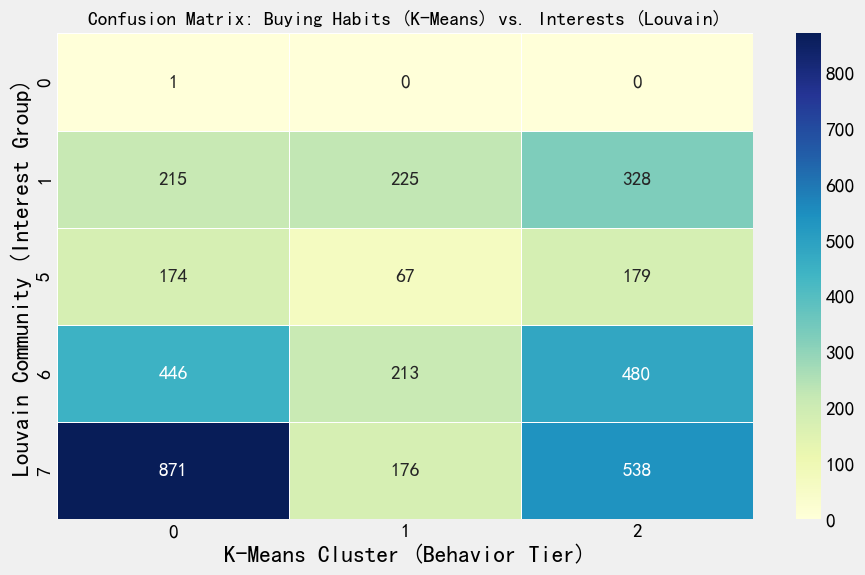

In [67]:
# 1. Identify Top Communities (to avoid analyzing tiny groups of 2 people)
# We analyze communities with at least 50 members
large_communities = rfm['Louvain_Cluster'].value_counts()
large_communities = large_communities[large_communities > 50].index.tolist()

community_data = []

for cluster_id in large_communities:
    # Get customers in this cluster
    members = rfm[rfm['Louvain_Cluster'] == cluster_id].index
    
    # A. Get RFM Stats (Behavior)
    # We use the original (non-scaled) RFM data for readability
    avg_spend = rfm.loc[members, 'Monetary'].mean()
    avg_freq = rfm.loc[members, 'Frequency'].mean()
    
    # B. Get Top Products (Interest)
    # Filter transaction data for these members
    txns = df_cleaned[df_cleaned['CustomerID'].isin(members)]
    # Get top 3 most frequent items
    top_items = txns['Description'].value_counts().head(3).index.tolist()
    top_items_str = ", ".join(top_items)
    
    # Append to list
    community_data.append({
        'Community ID': cluster_id,
        'Size': len(members),
        'Avg Spend (£)': round(avg_spend, 2),
        'Avg Frequency': round(avg_freq, 1),
        'Top Products': top_items_str
    })

# Convert to DataFrame
profile_df = pd.DataFrame(community_data).sort_values('Size', ascending=False)

print("\n--- Louvain Community Profile (Who are they?) ---")
# Display with full width to see product names
pd.set_option('display.max_colwidth', None)
display(profile_df)
pd.reset_option('display.max_colwidth')


# 2. Visual Comparison: Graph (Louvain) vs General (K-Means)
# Do 'High Spenders' (K-Means) belong to specific 'Interest Groups' (Louvain)?
print("\n--- Integration: RFM Clusters vs Graph Communities ---")

# Create a Cross-Tabulation
# We only use the top 5 Louvain communities to keep the heatmap readable
top_5_louvain = rfm['Louvain_Cluster'].value_counts().head(5).index
filtered_rfm = rfm[rfm['Louvain_Cluster'].isin(top_5_louvain)]

crosstab = pd.crosstab(filtered_rfm['Louvain_Cluster'], filtered_rfm['KMeans_Cluster'])

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title("Confusion Matrix: Buying Habits (K-Means) vs. Interests (Louvain)", fontsize=14)
plt.xlabel("K-Means Cluster (Behavior Tier)")
plt.ylabel("Louvain Community (Interest Group)")
plt.show()

### Step 7: Time Series Analysis - Sales Trend & Pattern Detection

Weekly Sales Time Series Analysis (Descriptive Visualization)


Weekly Time Series (Head):
InvoiceDate
2010-12-05    133979.14
2010-12-12    186902.55
2010-12-19    146960.76
2010-12-26     30511.23
2011-01-02         0.00
Freq: W-SUN, Name: TotalPrice, dtype: float64

Total number of weekly observations: 54


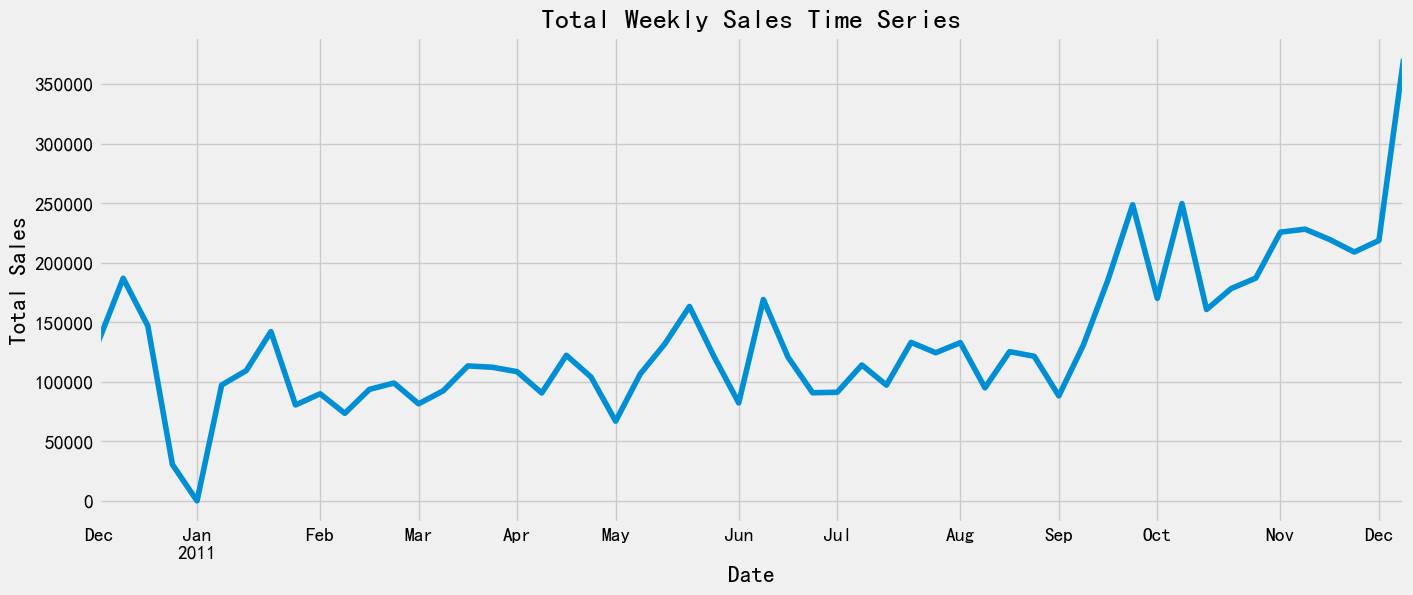

In [68]:
# 1. Prepare data for time series (set InvoiceDate as index)
ts_data = df_cleaned[['InvoiceDate', 'TotalPrice']].set_index('InvoiceDate')

# 2. Resample to get Total Sales per week (ending Sunday)
# The .fillna(0) handles weeks with no sales
ts_weekly = ts_data['TotalPrice'].resample('W-SUN').sum().fillna(0)

print("\nWeekly Time Series (Head):")
print(ts_weekly.head())
print(f"\nTotal number of weekly observations: {len(ts_weekly)}")

# Plot the weekly time series data
plt.figure(figsize=(15, 6))
ts_weekly.plot()
plt.title('Total Weekly Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.savefig('weekly_sales_timeseries.png')
plt.show()


Build time series (daily → weekly)

In [69]:
plt.style.use('fivethirtyeight')

print("\nBuilding time series...")

ts_daily = df_cleaned.set_index("InvoiceDate")["TotalPrice"].resample("D").sum()
ts_weekly = ts_daily.resample("W").sum().fillna(0)

# Rolling mean (4 weeks)
rolling_mean = ts_weekly.rolling(window=4).mean()

print("Daily points:", len(ts_daily))
print("Weekly points:", len(ts_weekly))


Building time series...
Daily points: 374
Weekly points: 54


Weekly trend plot, Seasonal decomposition, Monthly Sales Analysis

C:\Users\fhuur\AppData\Local\Temp\ipykernel_19832\224511565.py:11: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\fhuur\AppData\Local\Temp\ipykernel_19832\224511565.py:12: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  plt.savefig("weekly_sales_trend.png", dpi=300)
c:\Users\fhuur\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


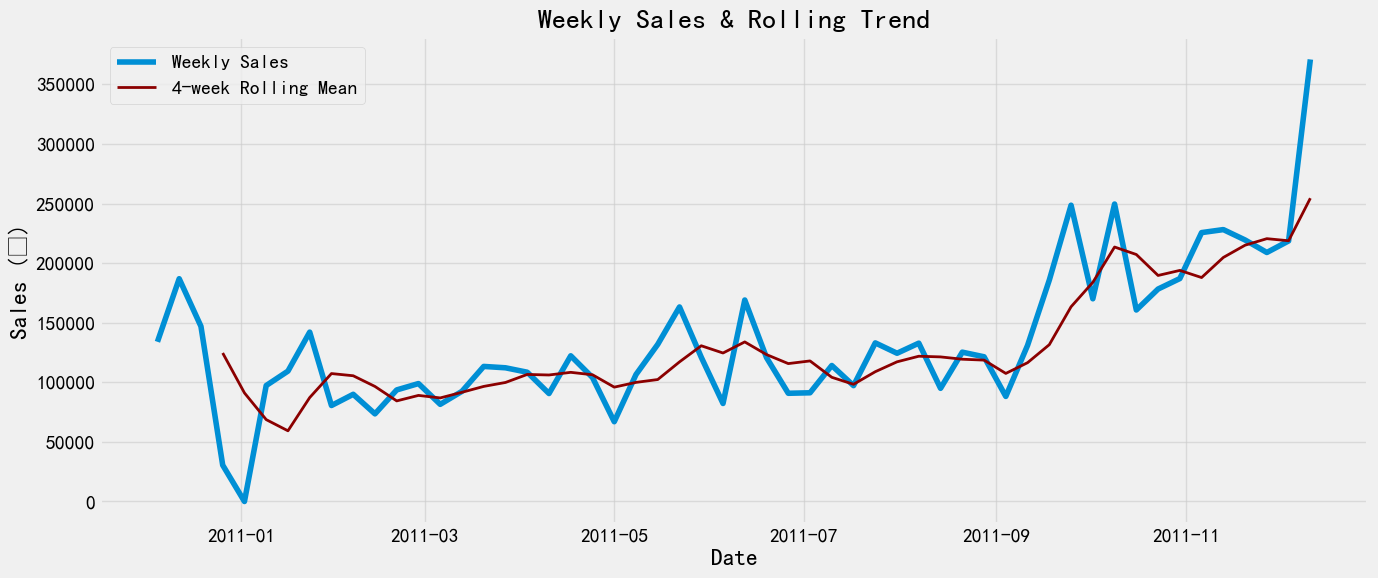


Weekly Table (First 12 Weeks):
Week Ending  Weekly Sales (£)  4-Week Rolling (£)
 2010-12-05         133979.14                 NaN
 2010-12-12         186902.55                 NaN
 2010-12-19         146960.76                 NaN
 2010-12-26          30511.23           124588.42
 2011-01-02              0.00            91093.64
 2011-01-09          97289.33            68690.33
 2011-01-16         109399.17            59299.93
 2011-01-23         142116.53            87201.26
 2011-01-30          80519.16           107331.05
 2011-02-06          89924.49           105489.84
 2011-02-13          73512.23            96518.10
 2011-02-20          93609.24            84391.28
Weekly observations: 54
Using period: 27


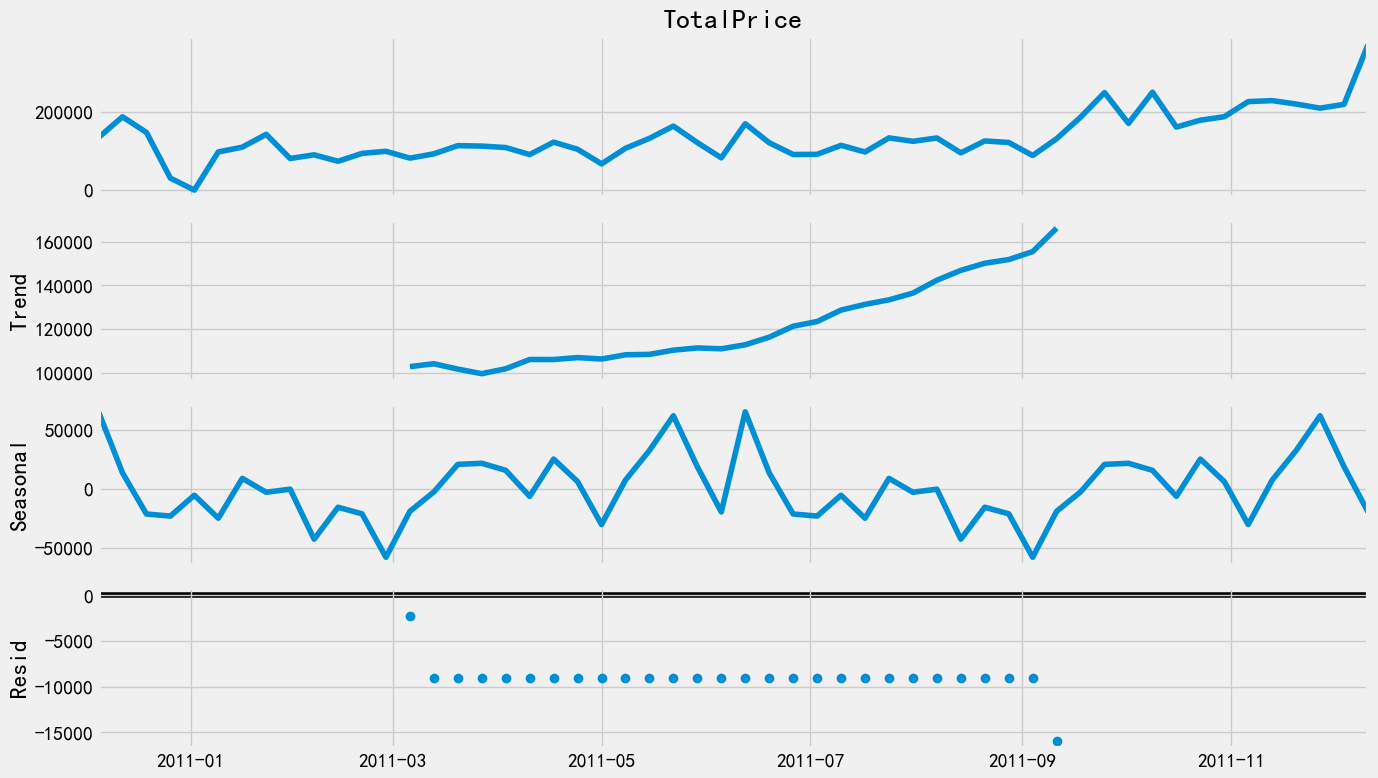


Seasonal Components (First 12 Weeks):
      Date  Observed  Trend  Seasonal  Residual
2010-12-05 133979.14    NaN  65194.32       NaN
2010-12-12 186902.55    NaN  13391.67       NaN
2010-12-19 146960.76    NaN -21540.39       NaN
2010-12-26  30511.23    NaN -23268.80       NaN
2011-01-02      0.00    NaN  -5594.39       NaN
2011-01-09  97289.33    NaN -25092.69       NaN
2011-01-16 109399.17    NaN   8704.70       NaN
2011-01-23 142116.53    NaN  -3069.18       NaN
2011-01-30  80519.16    NaN   -470.47       NaN
2011-02-06  89924.49    NaN -42881.79       NaN
2011-02-13  73512.23    NaN -15782.85       NaN
2011-02-20  93609.24    NaN -21346.76       NaN


C:\Users\fhuur\AppData\Local\Temp\ipykernel_19832\224511565.py:69: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\fhuur\AppData\Local\Temp\ipykernel_19832\224511565.py:70: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  plt.savefig("monthly_sales.png", dpi=300)
c:\Users\fhuur\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


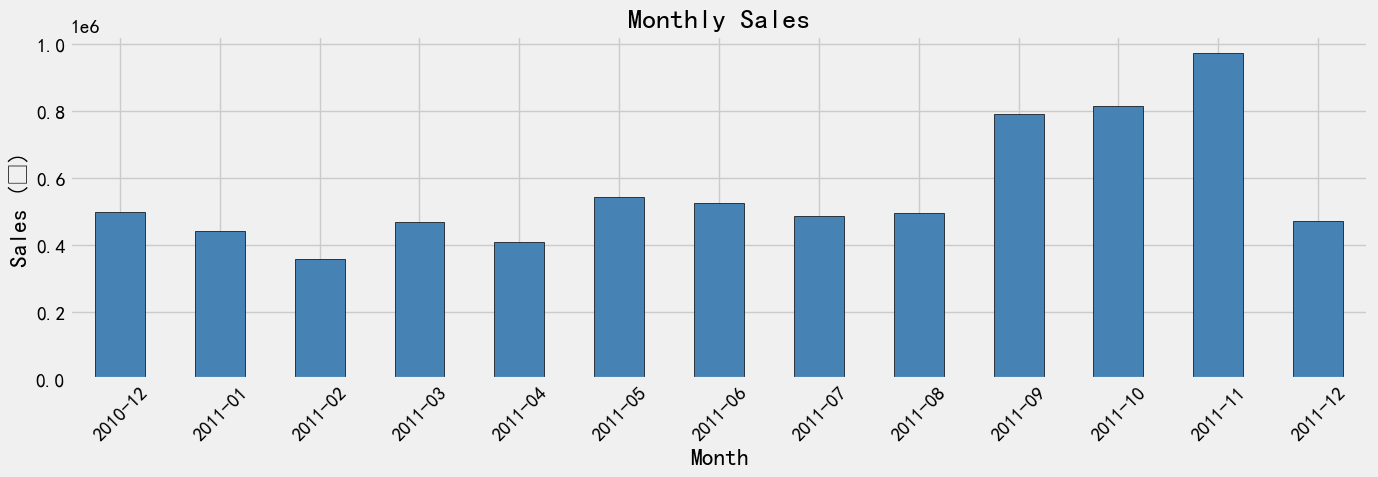


Monthly Sales:
Month
2010-12    498353.68
2011-01    442080.66
2011-02    355500.99
2011-03    466651.52
2011-04    406830.58
2011-05    542876.56
2011-06    524067.35
2011-07    484289.76
2011-08    495242.66
2011-09    791256.20
2011-10    815103.05
2011-11    973277.41
2011-12    470331.81


In [70]:
# Weekly trend plot

plt.figure(figsize=(14, 6))
plt.plot(ts_weekly, label="Weekly Sales")
plt.plot(rolling_mean, label="4-week Rolling Mean", linewidth=2, color="darkred")
plt.title("Weekly Sales & Rolling Trend")
plt.xlabel("Date")
plt.ylabel("Sales (£)")
plt.legend()
plt.grid(alpha=0.6)
plt.tight_layout()
plt.savefig("weekly_sales_trend.png", dpi=300)
plt.show()

# Show table (first 12 weeks)
weekly_table = pd.DataFrame({
    "Week Ending": ts_weekly.index.strftime("%Y-%m-%d"),
    "Weekly Sales (£)": ts_weekly.round(2),
    "4-Week Rolling (£)": rolling_mean.round(2)
})
print("\nWeekly Table (First 12 Weeks):")
print(weekly_table.head(12).to_string(index=False))

# Seasonal decomposition

n = len(ts_weekly)
target_period = 52  # annual pattern
period = min(target_period, max(2, n // 2))

print("Weekly observations:", n)
print("Using period:", period)

# Weekly seasonal decomposition

decomp = None
if n >= 2 * period:
    decomp = seasonal_decompose(ts_weekly, model="additive", period=period)

    fig = decomp.plot()
    fig.set_size_inches(14, 8)
    plt.tight_layout()
    plt.savefig("seasonal_decomposition.png", dpi=300)
    plt.show()
else:
    print("Not enough data for decomposition.")

if decomp is not None:
    table = pd.DataFrame({
        "Date": ts_weekly.index,
        "Observed": decomp.observed.round(2),
        "Trend": decomp.trend.round(2),
        "Seasonal": decomp.seasonal.round(2),
        "Residual": decomp.resid.round(2)
    })
    print("\nSeasonal Components (First 12 Weeks):")
    print(table.head(12).to_string(index=False))

# Monthly sales analysis

df_cleaned["Month"] = df_cleaned["InvoiceDate"].dt.to_period("M").astype(str)
monthly_sales = df_cleaned.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_sales.png", dpi=300)
plt.show()

print("\nMonthly Sales:")
print(monthly_sales.round(2).to_string())

Weekday pattern, Outlier Detection

C:\Users\fhuur\AppData\Local\Temp\ipykernel_19832\3818425776.py:14: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\fhuur\AppData\Local\Temp\ipykernel_19832\3818425776.py:15: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  plt.savefig("weekday_pattern.png", dpi=300)
c:\Users\fhuur\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 163 (\N{POUND SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


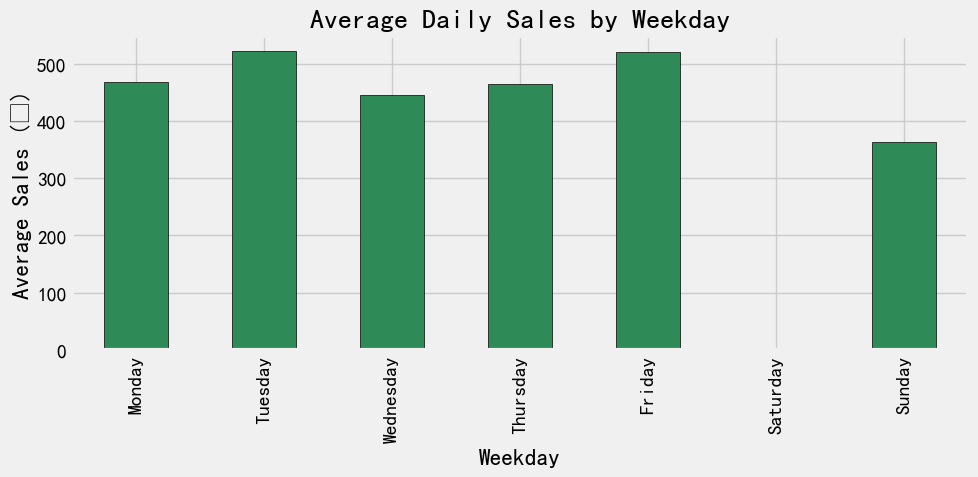


Weekday Average Sales:
Weekday
Monday       467.29
Tuesday      521.59
Wednesday    445.48
Thursday     463.70
Friday       520.30
Saturday        NaN
Sunday       363.46


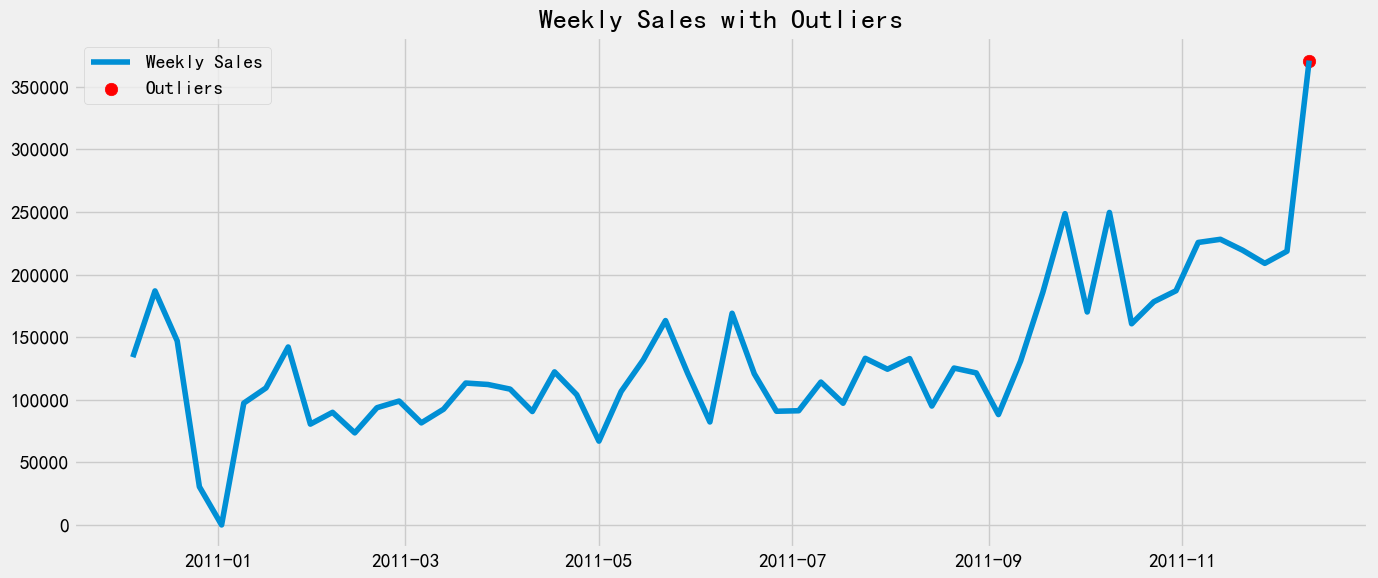


Outliers Found:
InvoiceDate
2011-12-11    370904.54
Freq: W-SUN


In [71]:
# Weekday pattern 

df_cleaned["Weekday"] = df_cleaned["InvoiceDate"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Daily sales grouped by weekday
daily_sales = df_cleaned.groupby(["InvoiceDate", "Weekday"])["TotalPrice"].sum().reset_index()
weekday_mean = daily_sales.groupby("Weekday")["TotalPrice"].mean().reindex(weekday_order)

plt.figure(figsize=(10, 5))
weekday_mean.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Average Daily Sales by Weekday")
plt.ylabel("Average Sales (£)")
plt.tight_layout()
plt.savefig("weekday_pattern.png", dpi=300)
plt.show()

print("\nWeekday Average Sales:")
print(weekday_mean.round(2).to_string())

# Outlier detection (Z-score method)

mean = ts_weekly.mean()
std = ts_weekly.std()

z = (ts_weekly - mean) / std
outliers = ts_weekly[z.abs() > 2.5]

plt.figure(figsize=(14, 6))
plt.plot(ts_weekly, label="Weekly Sales")
plt.scatter(outliers.index, outliers.values, color="red", s=80, label="Outliers")
plt.title("Weekly Sales with Outliers")
plt.legend()
plt.tight_layout()
plt.savefig("sales_outliers.png", dpi=300)
plt.show()

if len(outliers) > 0:
    print("\nOutliers Found:")
    print(outliers.round(2).to_string())
else:
    print("\nNo outliers detected.")

